In [1]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 76.7 MB/s eta 0:00:00


In [25]:
import numpy as np
np.set_printoptions(precision=2)
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import seaborn as sn
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import sweetviz as sv
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
import torch
import torch.nn as nn
import torch.optim as optim

DataSet :
---

In [26]:
data = pd.read_csv('brain_stroke.csv')
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


Information and descriptions about this DataSet :
---

In [27]:
data.shape

(4981, 11)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [29]:
data.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


In [30]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [31]:
for col in (data.select_dtypes(exclude=['float'])).columns:
    print(f"Categories of the '{col}' column: {data[col].unique()}")

Categories of the 'gender' column: ['Male' 'Female']
Categories of the 'hypertension' column: [0 1]
Categories of the 'heart_disease' column: [1 0]
Categories of the 'ever_married' column: ['Yes' 'No']
Categories of the 'work_type' column: ['Private' 'Self-employed' 'Govt_job' 'children']
Categories of the 'Residence_type' column: ['Urban' 'Rural']
Categories of the 'smoking_status' column: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
Categories of the 'stroke' column: [1 0]


In [32]:
data_dict = pd.DataFrame({'Variable': data.columns, 'Data Type': [data[col].dtype for col in data.columns]})

data_dict['Description'] = [
    'Gender of patient\nFemale, Male',
    'Age of patient (years)',
    '0 = does not have hypertention\n1 = has hypertension',
    '0 = does not have hear disease\n1 = has heart disease',
    'Marriage History\nYes(been or is married)\nNo(never married)',
    'Type of Work-\nPrivate: work for private firm\nSelf-employed\nGovt_job: work for government\nchildren: is a child (no work)',
    'Type of Residence Area\nUrban, Rural',
    'Average Glucose Level of patient (mg/dL)',
    'Body Mass Index',
    'Smoking Status of patient\nSmokes, Unknown, Former Smoker, Never Smoked',
    'Stroke History\n0 = has not had a stroke\n1 = has had a stroke'
]

data_dict = data_dict.style.set_properties(subset=['Description'], **{'width': '600px'})
data_dict

,Variable,Data Type,Description
0,gender,object,"Gender of patient Female, Male"
1,age,float64,Age of patient (years)
2,hypertension,int64,0 = does not have hypertention 1 = has hypertension
3,heart_disease,int64,0 = does not have hear disease 1 = has heart disease
4,ever_married,object,Marriage History Yes(been or is married) No(never married)
5,work_type,object,Type of Work- Private: work for private firm Self-employed Govt_job: work for government children: is a child (no work)
6,Residence_type,object,"Type of Residence Area Urban, Rural"
7,avg_glucose_level,float64,Average Glucose Level of patient (mg/dL)
8,bmi,float64,Body Mass Index
9,smoking_status,object,"Smoking Status of patient Smokes, Unknown, Former Smoker, Never Smoked"


X and Y :
---

In [10]:
X = data.loc[: , data.columns != 'stroke']
X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked
...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes


In [11]:
y = data['stroke']
y

,stroke
0,1
1,1
2,1
3,1
4,1
...,...
4976,0
4977,0
4978,0
4979,0


**Visualisation** for the data:
---



                                             |          | [  0%]   00:00 -> (? left)


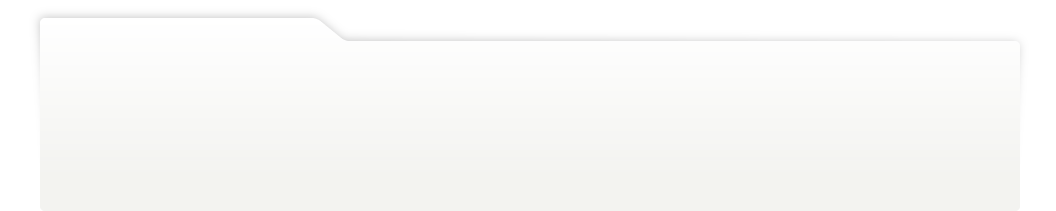
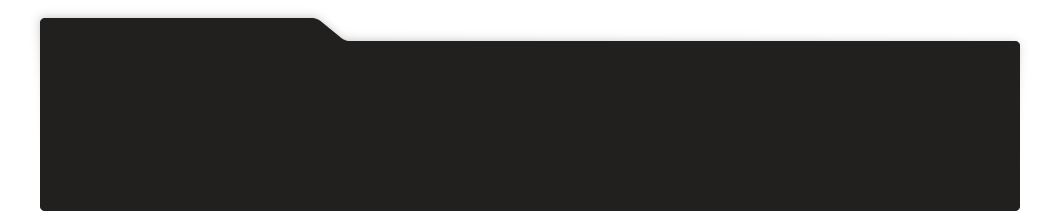
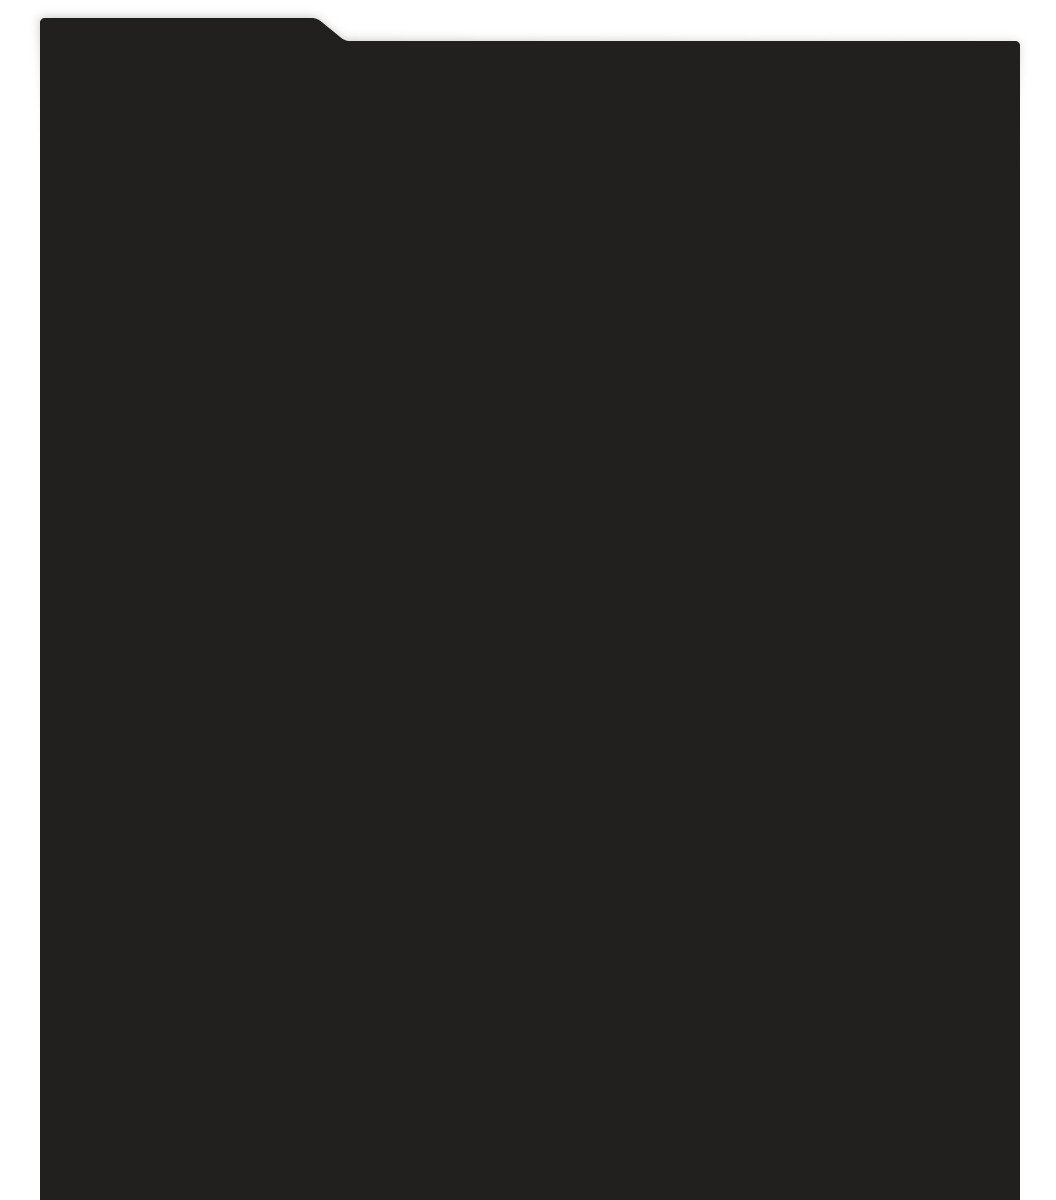
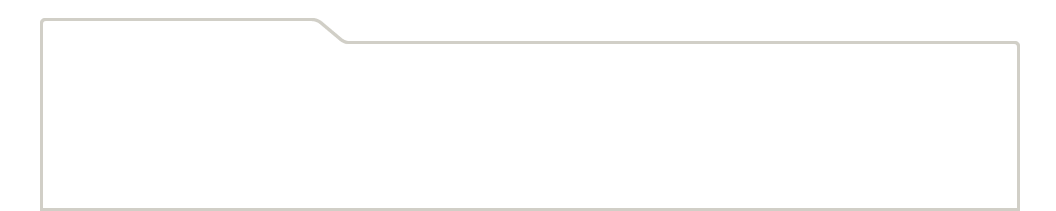
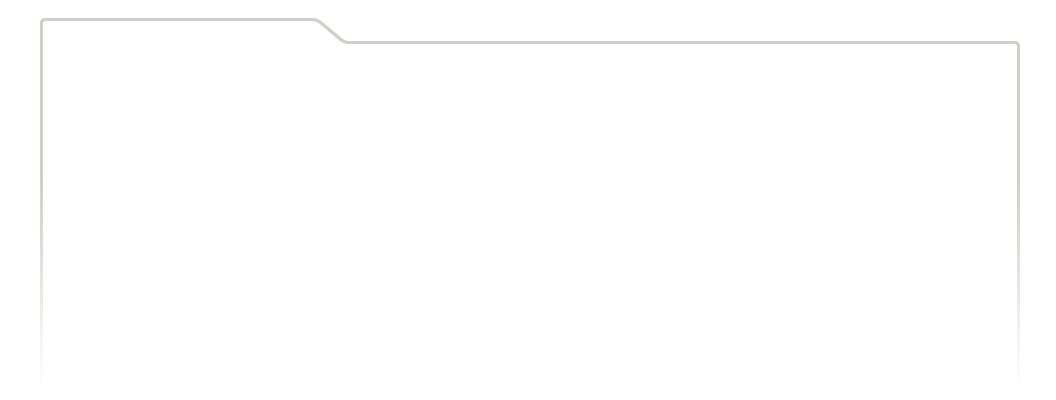
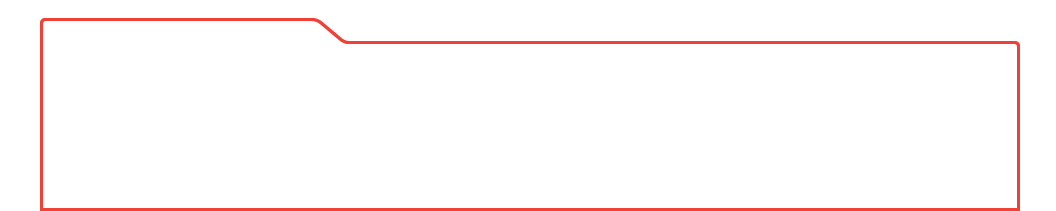
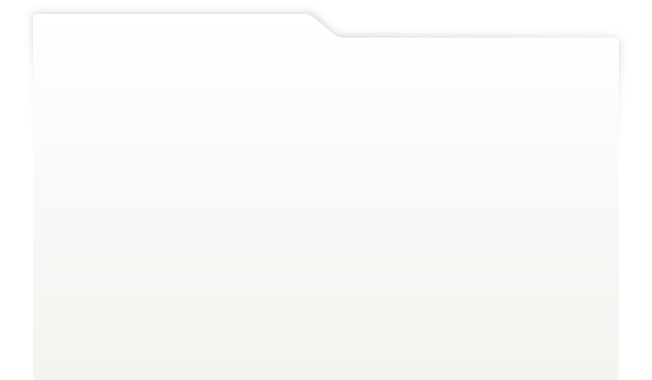
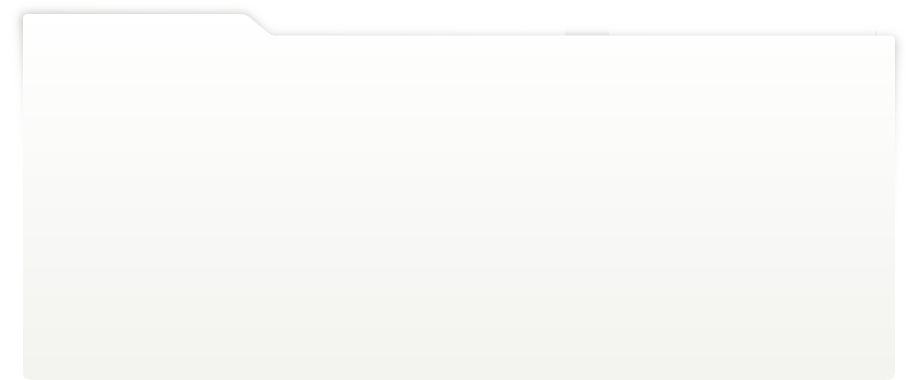
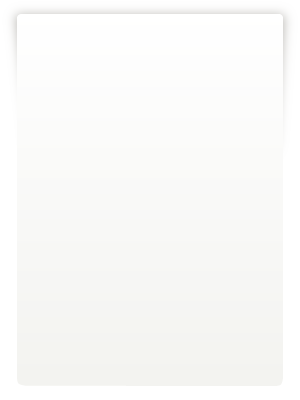
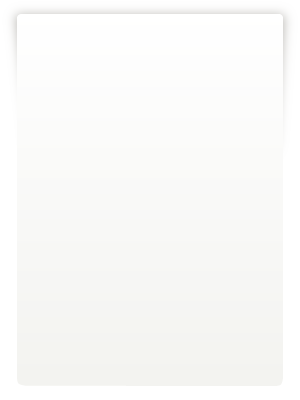
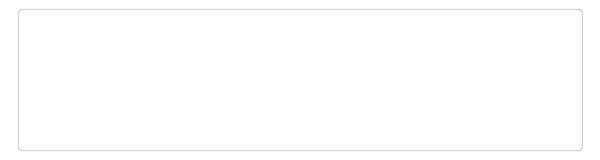
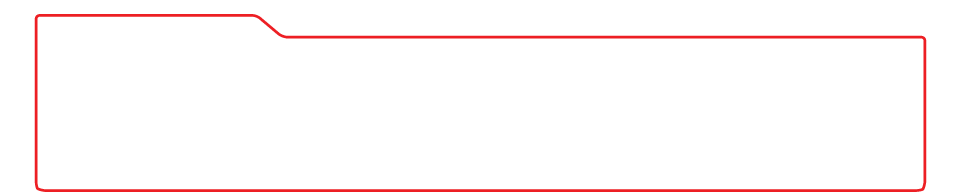
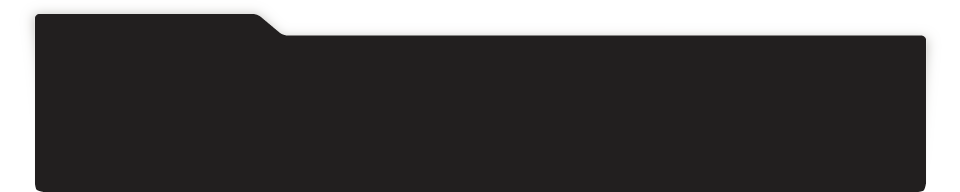
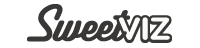
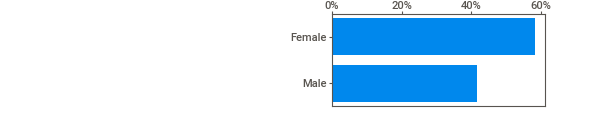
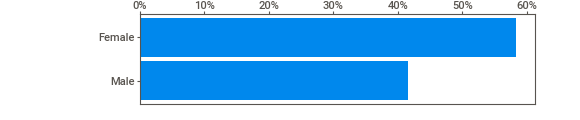
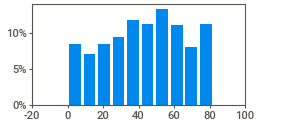
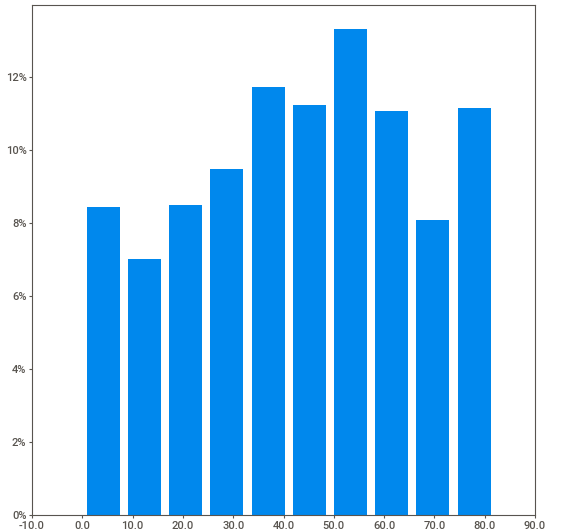
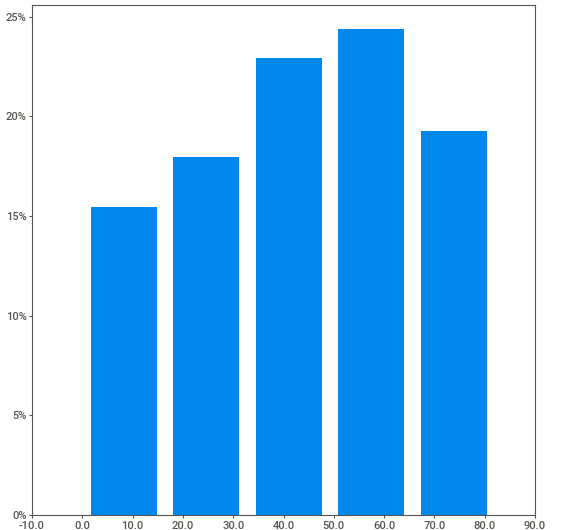
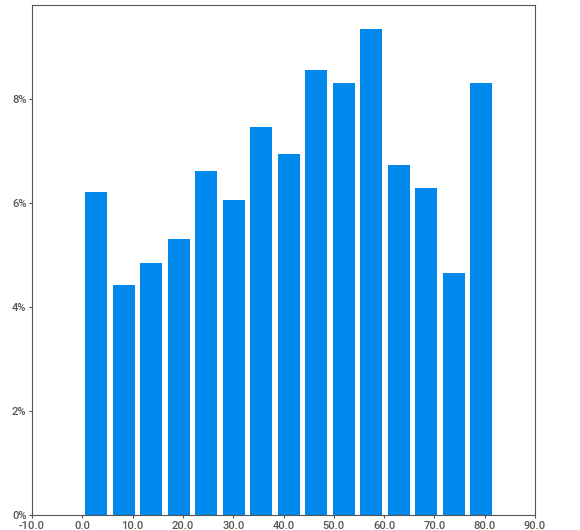
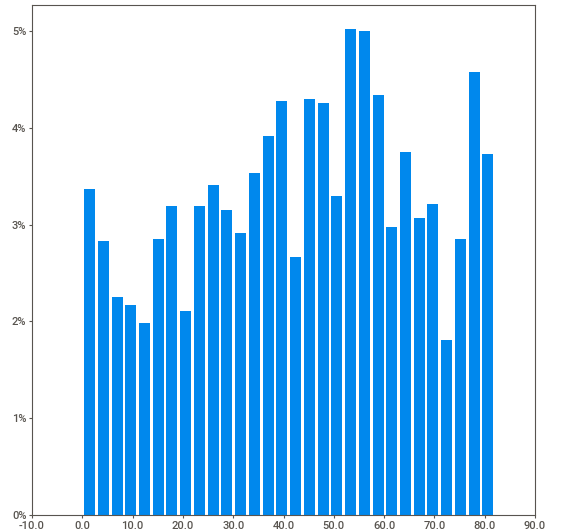
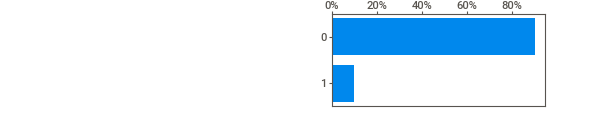
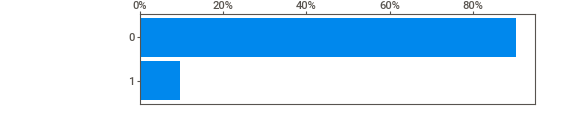
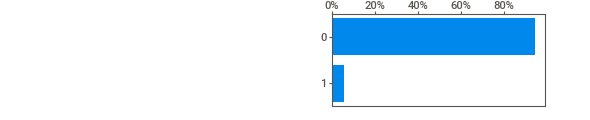
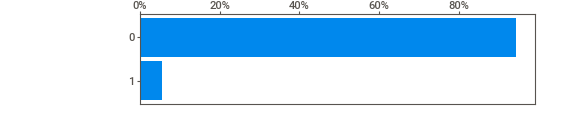
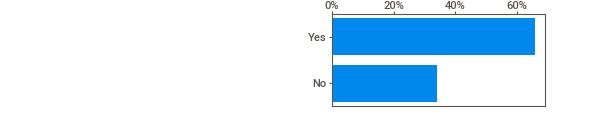
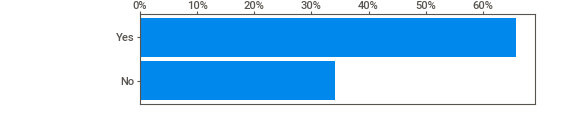
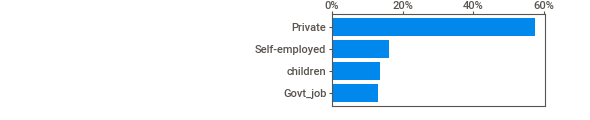
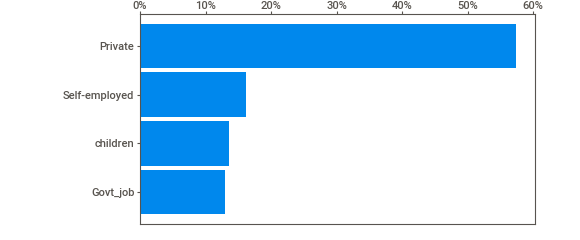
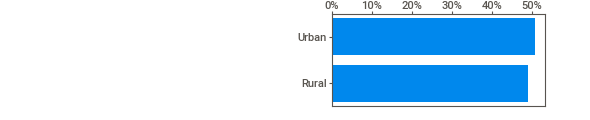
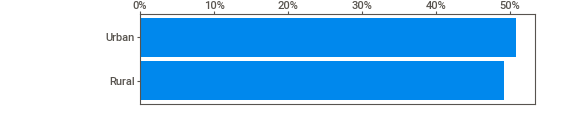
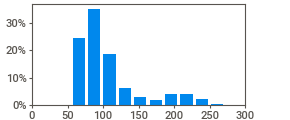
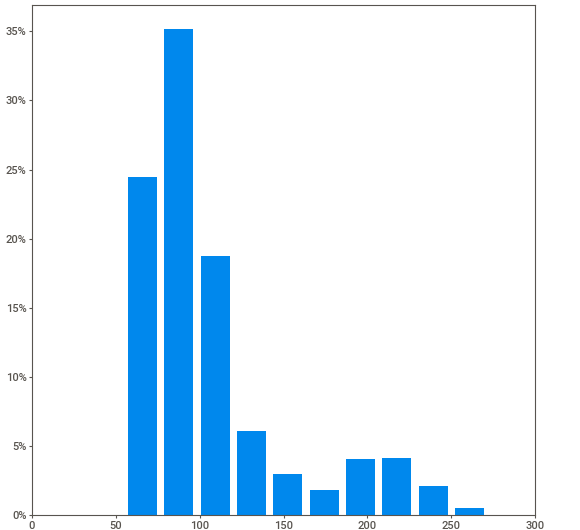
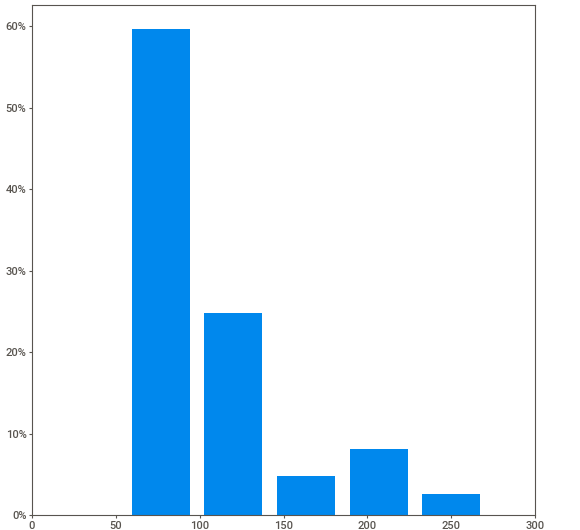
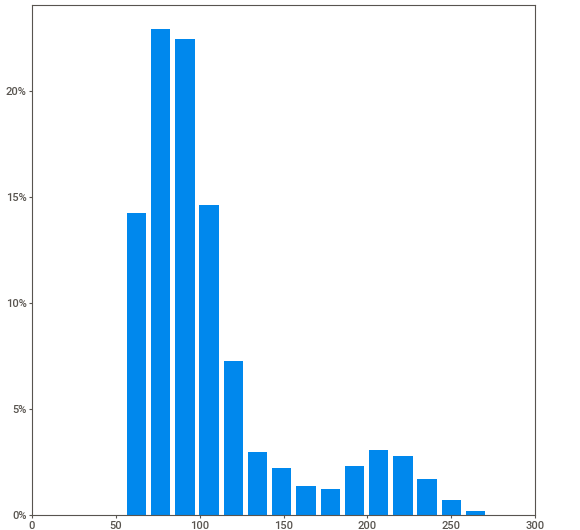
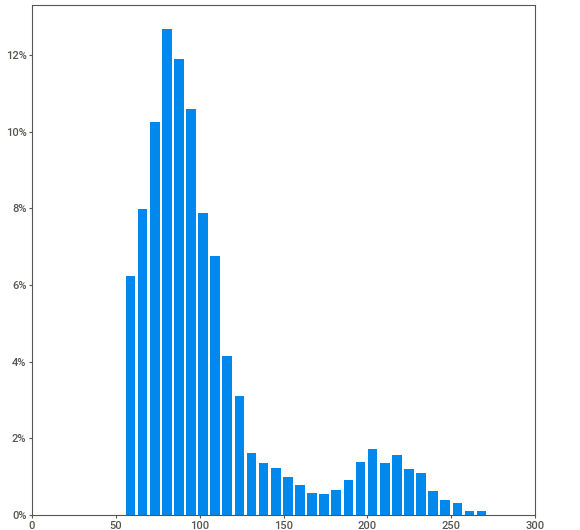
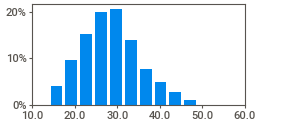
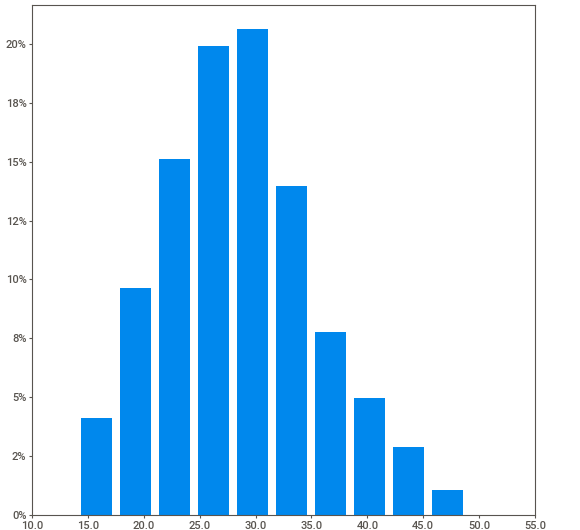
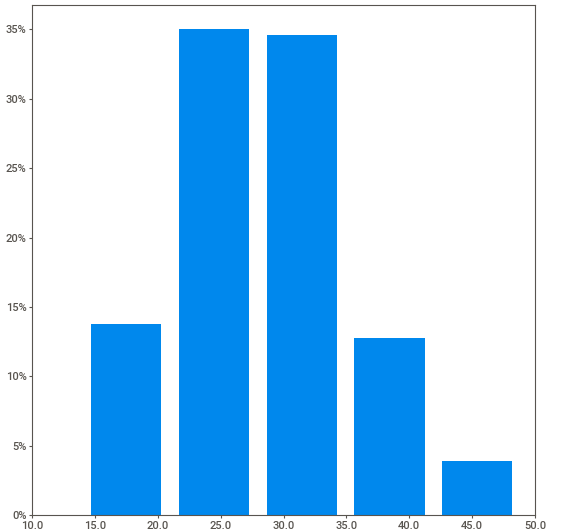
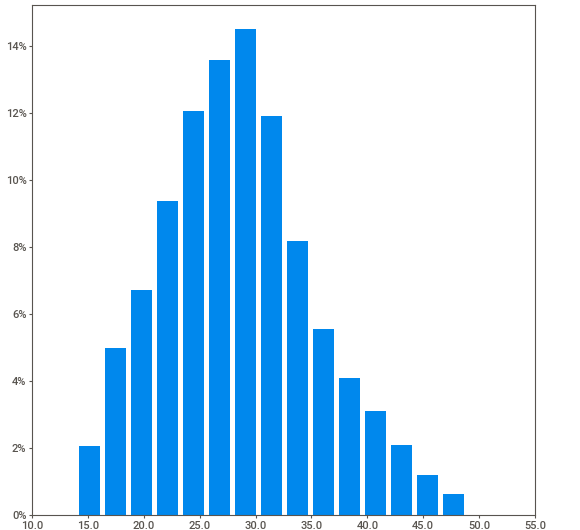
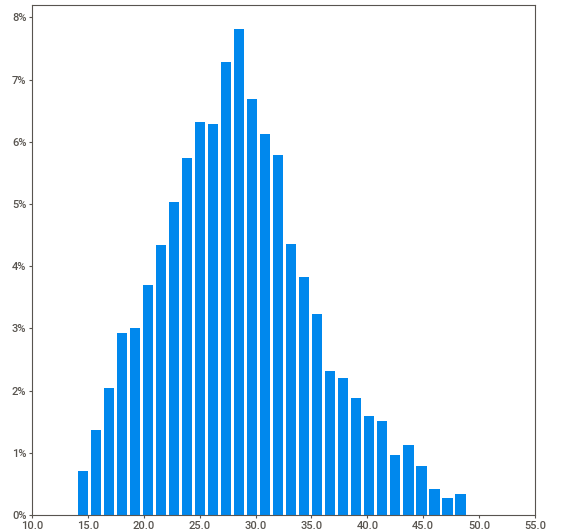
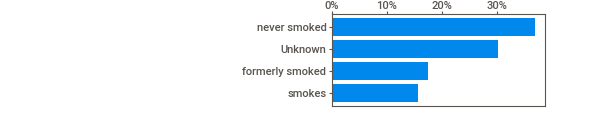
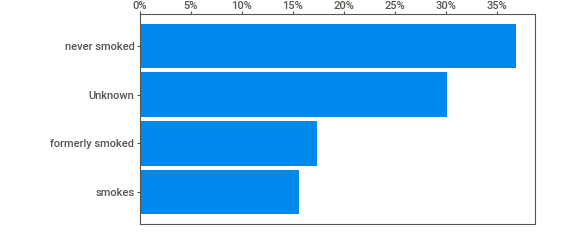
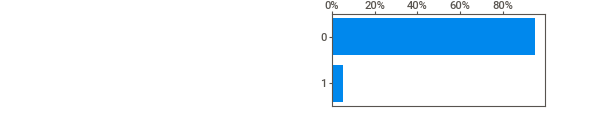
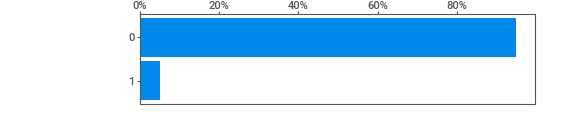
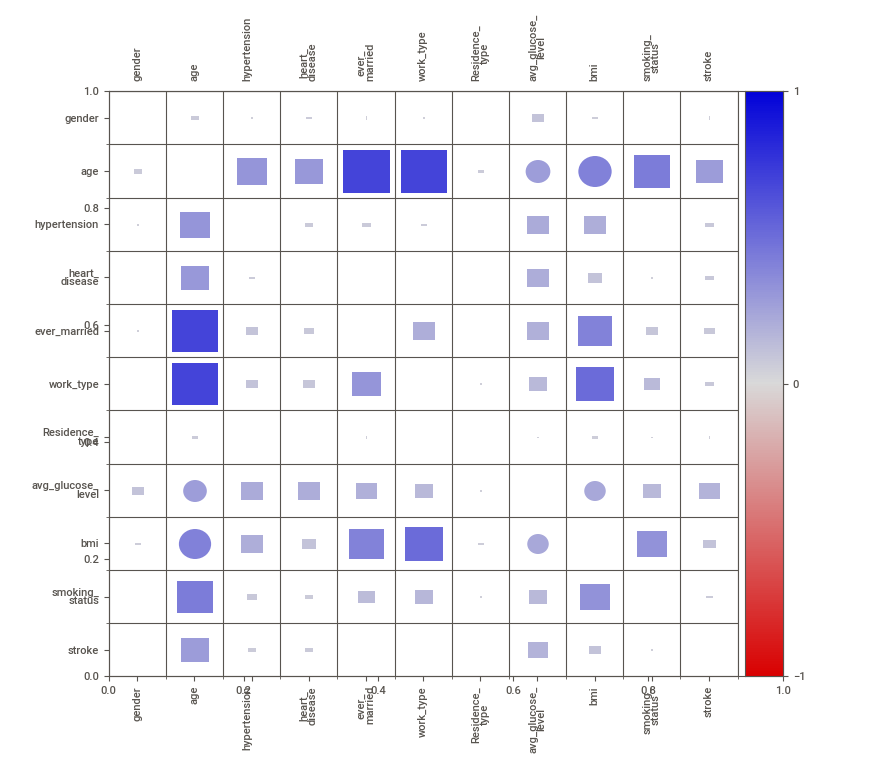
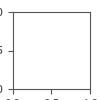

In [12]:
Sweetviz_EDA_brain_stroke = sv.analyze(pd.read_csv("brain_stroke.csv"))
Sweetviz_EDA_brain_stroke.show_notebook()

Smoking status vs Stroke
---

In [34]:
fig = px.pie(data, names='smoking_status', values='stroke',
             title = 'Representation of how smoking status can cause a stroke')
fig.show()

Numbers of smokers and Non-smokers by gender:
---

In [40]:
grouped_data = data.groupby(['gender', 'smoking_status']).size().reset_index(name='count')
figure = px.scatter(grouped_data,
                    x='gender',
                    y='count',
                    size='count',
                    color='smoking_status',
                    title='Number of Smokers and Non-Smokers by Gender',
                    )

figure.show()

Gender and chance of having a stroke
---

In [41]:
grouped_data = data.groupby(['gender', 'stroke']).size().reset_index(name='count')
figure = px.scatter(grouped_data,
                    x='gender',
                    y='count',
                    size='count' ,
                    color='stroke',
                    title='Gender and chance of having a stroke',
                    )

figure.show()

3D Represintaion of how gender, bmi and smoking status affect the chance of having a brain stroke
---

In [18]:
fig = px.scatter_3d(data, x='gender', y='smoking_status', z='bmi',
              color='stroke')
fig.show()

Get Dummies
---

In [42]:
data_encoded = pd.get_dummies(data, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)
data_encoded

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,True,False,False,True,True,False,False
1,80.0,0,1,105.92,32.5,1,True,True,True,False,False,False,False,True,False
2,49.0,0,0,171.23,34.4,1,False,True,True,False,False,True,False,False,True
3,79.0,1,0,174.12,24.0,1,False,True,False,True,False,False,False,True,False
4,81.0,0,0,186.21,29.0,1,True,True,True,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,41.0,0,0,70.15,29.8,0,True,False,True,False,False,False,True,False,False
4977,40.0,0,0,191.15,31.1,0,True,True,True,False,False,True,False,False,True
4978,45.0,1,0,95.02,31.8,0,False,True,False,False,False,False,False,False,True
4979,40.0,0,0,83.94,30.0,0,True,True,True,False,False,False,False,False,True


One Hot Encoder
---



In [43]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

encoded_array = encoder.fit_transform(data[categorical_columns])

encoded_columns = encoder.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns, index=data.index)

data_encoded = pd.concat([data.drop(columns=categorical_columns), encoded_df], axis=1)
data_encoded

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,80.0,0,1,105.92,32.5,1,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,49.0,0,0,171.23,34.4,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,79.0,1,0,174.12,24.0,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,81.0,0,0,186.21,29.0,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,41.0,0,0,70.15,29.8,0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4977,40.0,0,0,191.15,31.1,0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4978,45.0,1,0,95.02,31.8,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4979,40.0,0,0,83.94,30.0,0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


<Axes: >

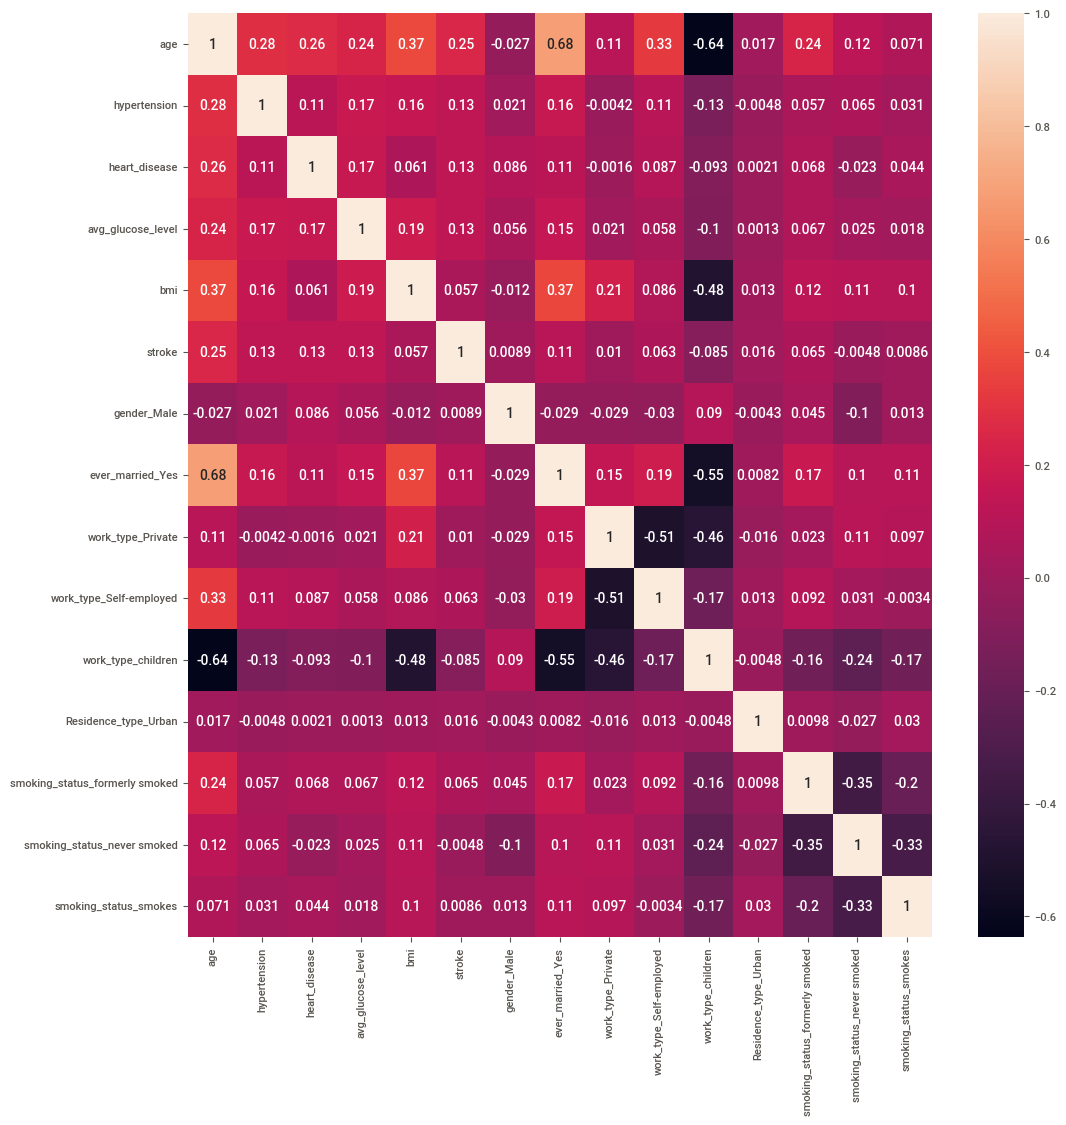

In [44]:
plt.figure(figsize=(12,12))
sn.heatmap(data_encoded.corr(),annot=True)

Scalar
---

In [47]:
scaler = StandardScaler()
X = pd.get_dummies(data.drop('stroke', axis=1), drop_first=True)
X_scaled = scaler.fit_transform(X)

# Show the data befor and after the scaling

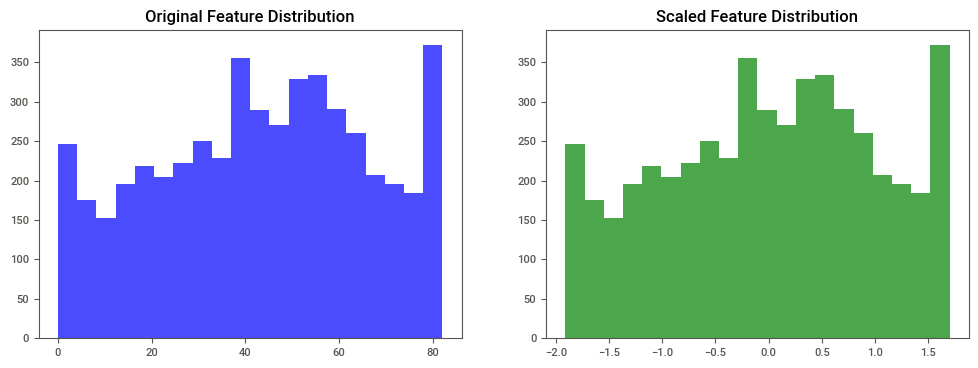

In [48]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(X.iloc[:, 0], bins=20, color='blue', alpha=0.7)
plt.title('Original Feature Distribution')

plt.subplot(1, 2, 2)
plt.hist(X_scaled[:, 0], bins=20, color='green', alpha=0.7)
plt.title('Scaled Feature Distribution')

plt.show()


# Split the data with 20% test data

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

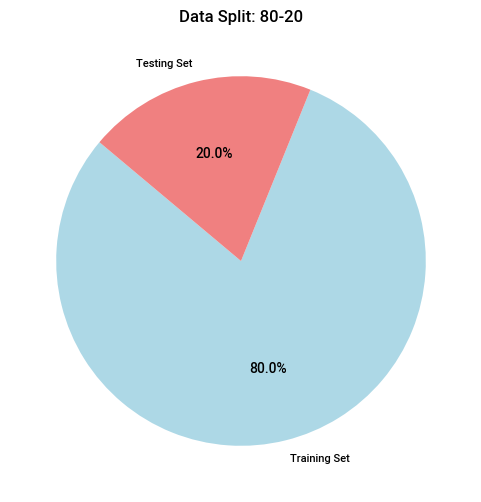

In [51]:
def plot_data_split(X_train, X_test, split_name):
    sizes = [len(X_train), len(X_test)]
    labels = ['Training Set', 'Testing Set']
    colors = ['lightblue', 'lightcoral']

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
    plt.title(f'Data Split: {split_name}')
    plt.show()

plot_data_split(X_train, X_test, "80-20")

# Build the model

In [52]:
def build_model(input_size):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_size,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model


# Train and evaluate the model

In [53]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, optimizer, num_epochs=50, batch_size=128):
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=num_epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='purple')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')
    return accuracy


In [54]:
input_size = X_train.shape[1]

# Using SGD Optimizer with 0.001 learning rate


Training on 80-20 split with SGD Optimizer:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9517 - loss: 0.5881 - val_accuracy: 0.9536 - val_loss: 0.5694
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9458 - loss: 0.5694 - val_accuracy: 0.9536 - val_loss: 0.5479
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9491 - loss: 0.5473 - val_accuracy: 0.9536 - val_loss: 0.5272
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9519 - loss: 0.5252 - val_accuracy: 0.9536 - val_loss: 0.5071
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.5075 - val_accuracy: 0.9536 - val_loss: 0.4877
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9454 - loss: 0.4902 - val_accuracy: 0.9536 - val_loss: 0.4690
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 - loss: 0.4695 - val_accuracy: 0.9536 - val_loss: 0.4511
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9494 - loss: 0.4549 - val_accuracy: 0.9536 - val_loss

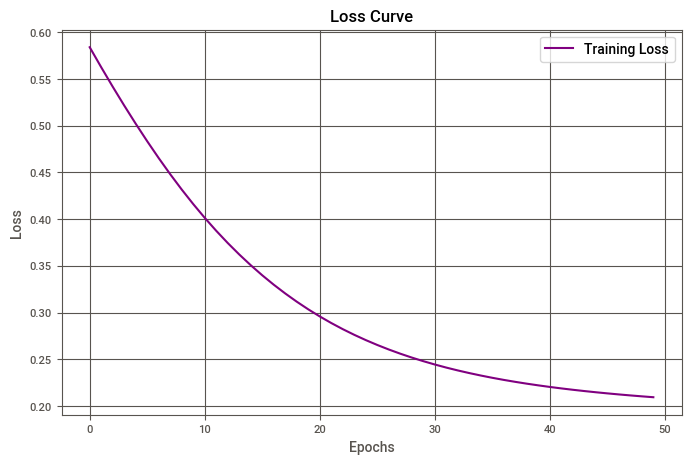

Test Accuracy: 94.58%


0.9458374977111816

In [55]:
print("Training on 80-20 split with SGD Optimizer:")
model_sgd = build_model(input_size)
train_and_evaluate(model_sgd, X_train, y_train, X_test, y_test, optimizer=SGD(learning_rate=0.001))

# SGD with with 0.01 learning rate

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9446 - loss: 0.2210 - val_accuracy: 0.9536 - val_loss: 0.1954
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9525 - loss: 0.1971 - val_accuracy: 0.9536 - val_loss: 0.1912
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9503 - loss: 0.1999 - val_accuracy: 0.9536 - val_loss: 0.1881
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9535 - loss: 0.1878 - val_accuracy: 0.9536 - val_loss: 0.1857
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9446 - loss: 0.2056 - val_accuracy: 0.9536 - val_loss: 0.1835
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9494 - loss: 0.1927 - val_accuracy: 0.9536 - val_loss: 0.1816
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9510 - loss: 0.1837 - val_accuracy: 0.9536 - val_loss: 0.1799
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9506 - loss: 0.1846 - val_accuracy: 0.9536 - val_loss

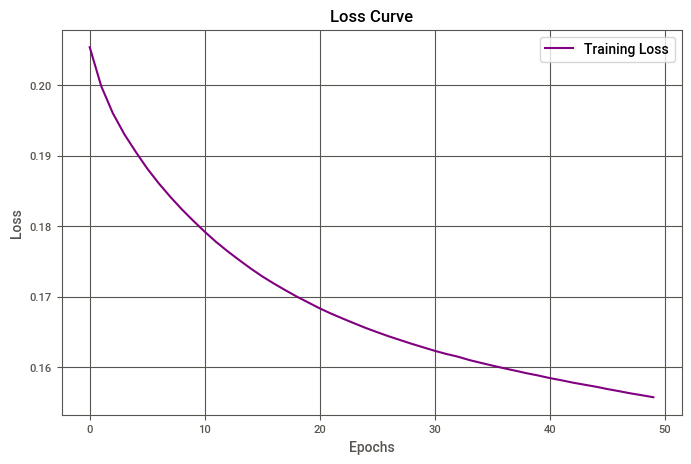

Test Accuracy: 94.58%


0.9458374977111816

In [56]:
train_and_evaluate(model_sgd, X_train, y_train, X_test, y_test, optimizer=SGD(learning_rate=0.01))

# Using Adam Optimizer


Training on 80-20 split with Adam Optimizer:
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8484 - loss: 0.4464 - val_accuracy: 0.9536 - val_loss: 0.1814
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9469 - loss: 0.1908 - val_accuracy: 0.9536 - val_loss: 0.1626
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9509 - loss: 0.1600 - val_accuracy: 0.9536 - val_loss: 0.1585
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9455 - loss: 0.1649 - val_accuracy: 0.9536 - val_loss: 0.1597
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9492 - loss: 0.1490 - val_accuracy: 0.9536 - val_loss: 0.1590
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9530 - loss: 0.1352 - val_accuracy: 0.9536 - val_loss: 0.1610
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9477 - loss: 0.1481 - val_accuracy: 0.9536 - val_loss: 0.1599
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9501 - l

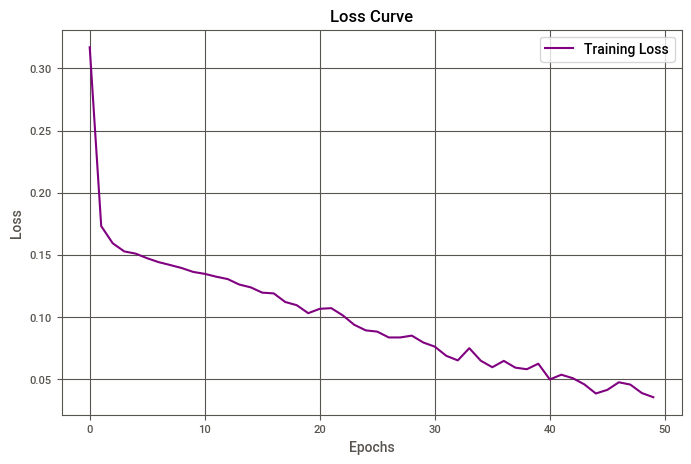

Test Accuracy: 92.08%


0.920762300491333

In [58]:
print("Training on 80-20 split with Adam Optimizer:")
model_adam = build_model(input_size)
train_and_evaluate(model_adam, X_train, y_train, X_test, y_test, optimizer=Adam(learning_rate=0.001))

# Using Adam Optimizer with another learning rate

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9377 - loss: 0.2673 - val_accuracy: 0.9536 - val_loss: 0.1833
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9521 - loss: 0.1563 - val_accuracy: 0.9523 - val_loss: 0.1855
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9566 - loss: 0.1306 - val_accuracy: 0.9536 - val_loss: 0.1935
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9533 - loss: 0.1138 - val_accuracy: 0.9511 - val_loss: 0.2069
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9526 - loss: 0.1285 - val_accuracy: 0.9448 - val_loss: 0.2216
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9604 - loss: 0.1062 - val_accuracy: 0.9486 - val_loss: 0.2175
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9527 - loss: 0.1261 - val_accuracy: 0.9348 - val_loss: 0.2426
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9630 - loss: 0.1137 - val_accuracy: 0.9285 - val_los

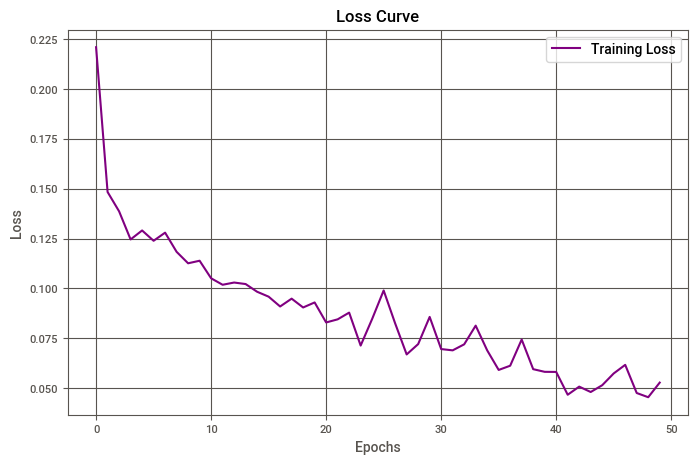

Test Accuracy: 92.78%


0.9277833700180054

In [59]:
train_and_evaluate(model_adam, X_train, y_train, X_test, y_test, optimizer=Adam(learning_rate=0.01))

# split (70-30)

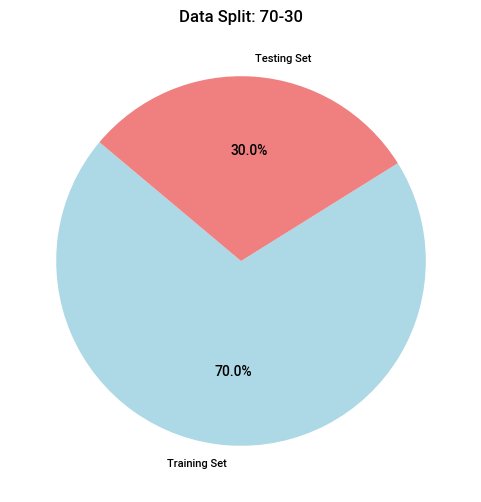

In [60]:
X = data.loc[:, data.columns != 'stroke']
y = data['stroke']

# Data preprocessing
scaler = StandardScaler()
X = pd.get_dummies(data.drop('stroke', axis=1), drop_first=True)
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
plot_data_split(X_train, X_test, "70-30")
input_size = X_train.shape[1]

# Using SGD Optimizer with 30% test data and 0.001 learning rate

Training on 70-30 split with SGD Optimizer:
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9052 - loss: 0.6453 - val_accuracy: 0.9370 - val_loss: 0.6345
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9264 - loss: 0.6335 - val_accuracy: 0.9513 - val_loss: 0.6225
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9463 - loss: 0.6205 - val_accuracy: 0.9542 - val_loss: 0.6108
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9496 - loss: 0.6104 - val_accuracy: 0.9542 - val_loss: 0.5992
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9422 - loss: 0.6000 - val_accuracy: 0.9556 - val_loss: 0.5878
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9590 - loss: 0.5845 - val_accuracy: 0.9556 - val_loss: 0.5766
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9522 - loss: 0.5761 - val_accuracy: 0.9556 - val_loss: 0.5655
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9473 - loss: 0.5655 - val_accuracy: 0.9556 - val_loss: 0.5546
Ep

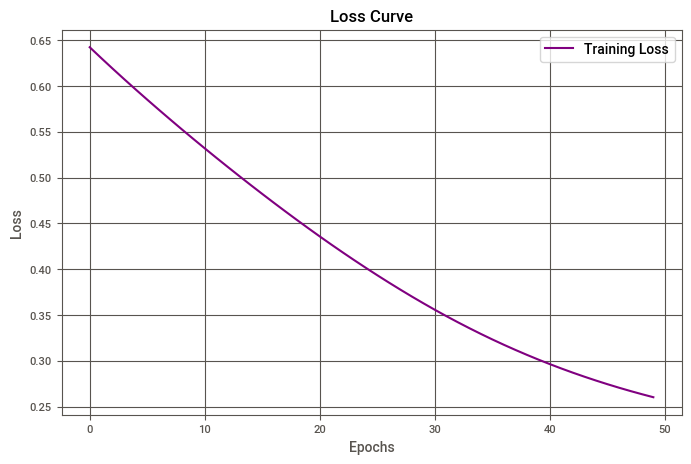

Test Accuracy: 94.78%


0.947826087474823

In [61]:
print("Training on 70-30 split with SGD Optimizer:")
model_sgd = build_model(input_size)
train_and_evaluate(model_sgd, X_train, y_train, X_test, y_test, optimizer=SGD(learning_rate=0.001))

# Using SGD Optimizer with 30% test data and  0.01 learning rate

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9465 - loss: 0.2583 - val_accuracy: 0.9556 - val_loss: 0.2221
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9419 - loss: 0.2430 - val_accuracy: 0.9556 - val_loss: 0.2064
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9501 - loss: 0.2161 - val_accuracy: 0.9556 - val_loss: 0.1970
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9524 - loss: 0.2021 - val_accuracy: 0.9556 - val_loss: 0.1912
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9495 - loss: 0.2048 - val_accuracy: 0.9556 - val_loss: 0.1872
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9483 - loss: 0.2045 - val_accuracy: 0.9556 - val_loss: 0.1843
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9530 - loss: 0.1880 - val_accuracy: 0.9556 - val_loss: 0.1821
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9516 - loss: 0.1918 - val_accuracy: 0.9556 - val_loss

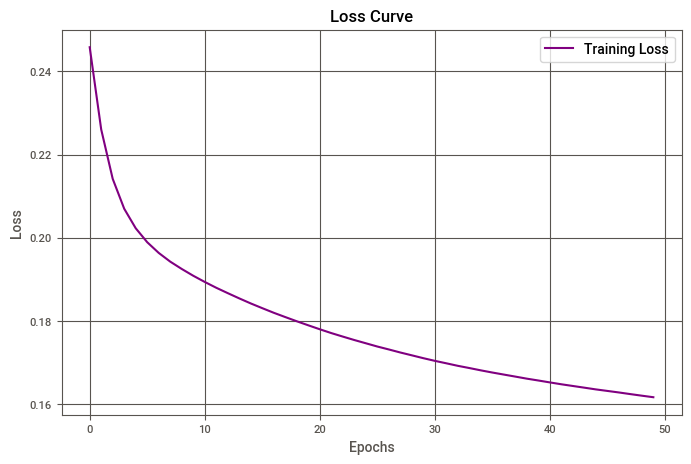

Test Accuracy: 94.78%


0.947826087474823

In [62]:
train_and_evaluate(model_sgd, X_train, y_train, X_test, y_test, optimizer=SGD(learning_rate=0.01))

# Using Adam Optimizer with 30% test data and 0.001 learning rate

Training on 70-30 split with Adam Optimizer:
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9374 - loss: 0.4402 - val_accuracy: 0.9556 - val_loss: 0.1917
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9543 - loss: 0.1724 - val_accuracy: 0.9556 - val_loss: 0.1643
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9489 - loss: 0.1662 - val_accuracy: 0.9556 - val_loss: 0.1599
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9497 - loss: 0.1501 - val_accuracy: 0.9556 - val_loss: 0.1610
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9504 - loss: 0.1490 - val_accuracy: 0.9556 - val_loss: 0.1598
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9497 - loss: 0.1476 - val_accuracy: 0.9556 - val_loss: 0.1595
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9551 - loss: 0.1338 - val_accuracy: 0.9556 - val_loss: 0.1619
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9490 - l

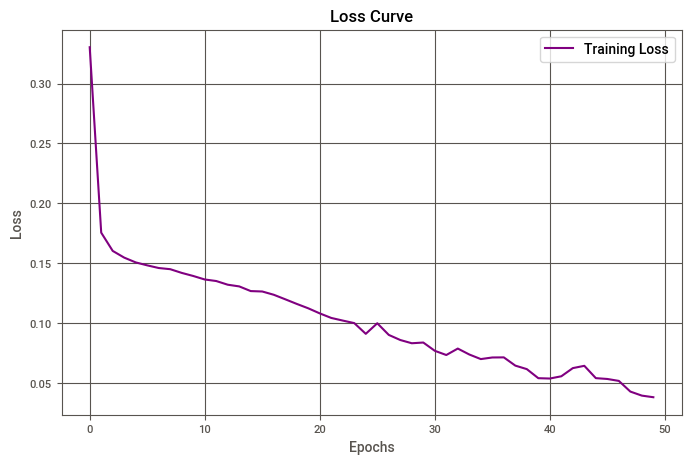

Test Accuracy: 93.71%


0.9371237754821777

In [63]:
print("Training on 70-30 split with Adam Optimizer:")
model_adam = build_model(input_size)
train_and_evaluate(model_adam, X_train, y_train, X_test, y_test, optimizer=Adam(learning_rate=0.001))

# Using Adam Optimizer with 30% test data and 0.01 learning rate

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9342 - loss: 0.3449 - val_accuracy: 0.9556 - val_loss: 0.1701
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9529 - loss: 0.1436 - val_accuracy: 0.9556 - val_loss: 0.1818
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9510 - loss: 0.1345 - val_accuracy: 0.9542 - val_loss: 0.1815
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9531 - loss: 0.1380 - val_accuracy: 0.9556 - val_loss: 0.2051
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9529 - loss: 0.1364 - val_accuracy: 0.9341 - val_loss: 0.2223
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9536 - loss: 0.1193 - val_accuracy: 0.9513 - val_loss: 0.2196
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9530 - loss: 0.1192 - val_accuracy: 0.9499 - val_loss: 0.2502
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9482 - loss: 0.1175 - val_accuracy: 0.9456 - val_loss

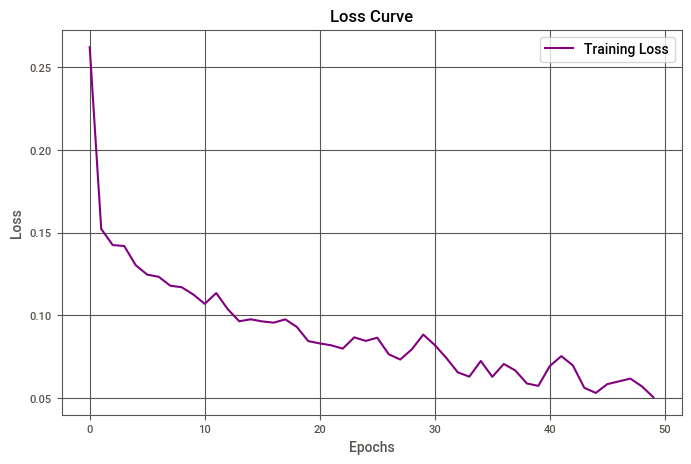

Test Accuracy: 93.18%


0.9317725896835327

In [64]:
train_and_evaluate(model_adam, X_train, y_train, X_test, y_test, optimizer=Adam(learning_rate=0.01))

#Using torch library

# Convert Data to Tensors

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f'Training Tensor Shape: {X_train_tensor.shape}')
print(f'Testing Tensor Shape: {X_test_tensor.shape}')


Training Tensor Shape: torch.Size([3984, 14])
Testing Tensor Shape: torch.Size([997, 14])


# Define the class of the NN

In [ ]:
class StrokePredictionModel(nn.Module):
    def __init__(self, input_size):
        super(StrokePredictionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.sigmoid(self.fc5(x))
        return x


# Loss Function and Optimizer with SGD

In [ ]:
input_size = X_train.shape[1]
model = StrokePredictionModel(input_size)
# print(model)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# Train the Model using SGD optimizer


Epoch [10/100], Loss: 0.6795
Epoch [20/100], Loss: 0.6770
Epoch [30/100], Loss: 0.6745
Epoch [40/100], Loss: 0.6721
Epoch [50/100], Loss: 0.6697
Epoch [60/100], Loss: 0.6672
Epoch [70/100], Loss: 0.6648
Epoch [80/100], Loss: 0.6624
Epoch [90/100], Loss: 0.6601
Epoch [100/100], Loss: 0.6577


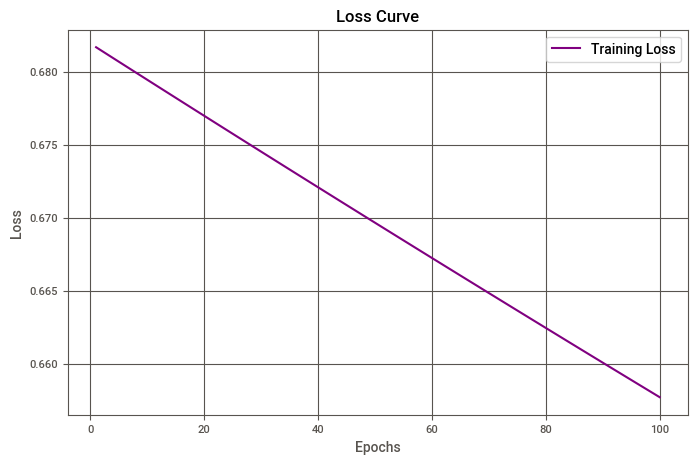

In [ ]:
losses = []
num_epochs = 100
for epoch in range(num_epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, color='purple', label='Training Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Test the model with SGD optimizer

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_class = (y_pred > 0.5).float()

    accuracy = (y_pred_class == y_test_tensor).sum().item() / y_test_tensor.size(0)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 94.58%


#Train the Model using adam Optimizer


Epoch [10/100], Loss: 0.4796
Epoch [20/100], Loss: 0.2142
Epoch [30/100], Loss: 0.1986
Epoch [40/100], Loss: 0.1744
Epoch [50/100], Loss: 0.1647
Epoch [60/100], Loss: 0.1607
Epoch [70/100], Loss: 0.1570
Epoch [80/100], Loss: 0.1547
Epoch [90/100], Loss: 0.1525
Epoch [100/100], Loss: 0.1502


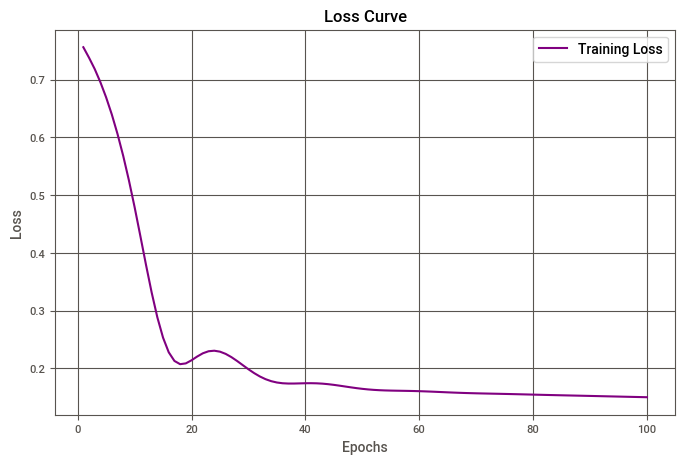

In [ ]:
input_size = X_train.shape[1]
model = StrokePredictionModel(input_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
losses = []
num_epochs = 100
for epoch in range(num_epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, color='purple', label='Training Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Test the Model with Adam

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_class = (y_pred > 0.5).float()

    accuracy = (y_pred_class == y_test_tensor).sum().item() / y_test_tensor.size(0)
    print(f'Test Accuracy: {accuracy * 100:.2f}%')

Test Accuracy: 94.58%
